<a href="https://colab.research.google.com/github/mnkshii/sign-language/blob/main/signlanguage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle

In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = "heenadanu01"
os.environ['KAGGLE_KEY'] = "30630377"

In [ ]:
!kaggle datasets download -d risangbaskoro/wlasl-processed

Dataset URL: https://www.kaggle.com/datasets/risangbaskoro/wlasl-processed
License(s): other
wlasl-processed.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -o wlasl-processed.zip -d /content/WLASL

Streaming output truncated to the last 5000 lines.
  inflating: /content/WLASL/videos/43596.mp4  
  inflating: /content/WLASL/videos/43598.mp4  
  inflating: /content/WLASL/videos/43599.mp4  
  inflating: /content/WLASL/videos/43671.mp4  
  inflating: /content/WLASL/videos/43672.mp4  
  inflating: /content/WLASL/videos/43674.mp4  
  inflating: /content/WLASL/videos/43677.mp4  
  inflating: /content/WLASL/videos/43679.mp4  
  inflating: /content/WLASL/videos/43680.mp4  
  inflating: /content/WLASL/videos/43681.mp4  
  inflating: /content/WLASL/videos/43682.mp4  
  inflating: /content/WLASL/videos/43684.mp4  
  inflating: /content/WLASL/videos/43689.mp4  
  inflating: /content/WLASL/videos/43697.mp4  
  inflating: /content/WLASL/videos/43698.mp4  
  inflating: /content/WLASL/videos/43700.mp4  
  inflating: /content/WLASL/videos/43703.mp4  
  inflating: /content/WLASL/videos/43726.mp4  
  inflating: /content/WLASL/videos/43727.mp4  
  inflating: /content/WLASL/videos/43729.mp4  
  inflati

In [ ]:
!pip install tensorflow opencv-python mediapipe matplotlib scikit-learn flask

Loading WLASL JSON...
Total gloss entries: 2000
Filtered gloss count: 9
Total usable videos: 84
Example samples: [('/content/WLASL/videos/69302.mp4', 'drink'), ('/content/WLASL/videos/65539.mp4', 'drink'), ('/content/WLASL/videos/17710.mp4', 'drink'), ('/content/WLASL/videos/17733.mp4', 'drink'), ('/content/WLASL/videos/65540.mp4', 'drink')]
Extracting frames from videos...
Processed 0/84 videos
Processed 10/84 videos
Processed 20/84 videos
Processed 30/84 videos
Processed 40/84 videos
Processed 50/84 videos
Processed 60/84 videos
Processed 70/84 videos
Processed 80/84 videos
Final X shape: (64, 10, 64, 64, 1)
Final y shape: (64,)
Train shape: (51, 10, 64, 64, 1)
Test shape: (13, 10, 64, 64, 1)
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.2145 - loss: 2.3012
Epoch 1: val_accuracy improved from None to 0.07692, saving model to /content/model/sign_lstm_model.keras

Epoch 1: finished saving model to /content/model/sign_lstm_model.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 821ms

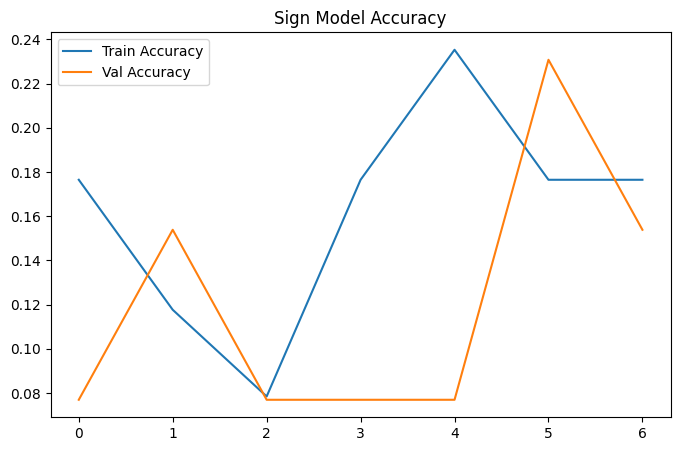

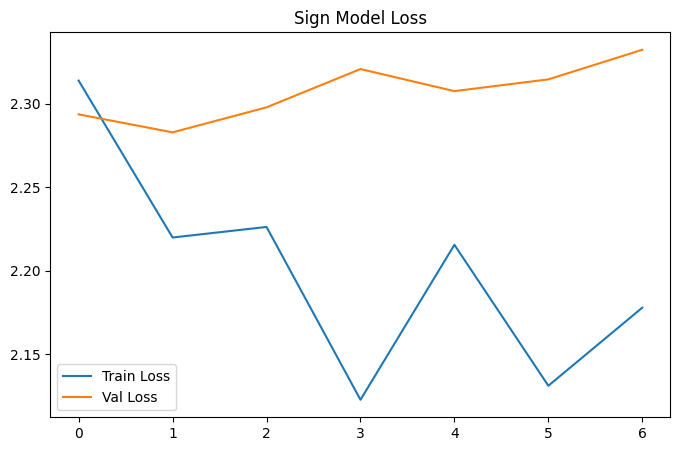

In [ ]:
# ============================================================
# WLASL SIGN LANGUAGE RECOGNITION USING CNN + LSTM
# GOOGLE COLAB READY
# ============================================================

import os
import json
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    TimeDistributed, LSTM, Input, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# -------------------------------
# CONFIG
# -------------------------------
IMG_SIZE = 64
SEQUENCE_LENGTH = 10
BATCH_SIZE = 8
EPOCHS = 20

# Select only a few glosses first (best for project)
SELECTED_GLOSSES = [
    'hello', 'thanks', 'yes', 'no', 'please',
    'help', 'love', 'sorry', 'eat', 'drink'
]

# Paths
WLASL_ROOT = "/content/WLASL"
JSON_PATH = os.path.join(WLASL_ROOT, "WLASL_v0.3.json")
VIDEO_DIR = os.path.join(WLASL_ROOT, "videos")

MODEL_DIR = "/content/model"
os.makedirs(MODEL_DIR, exist_ok=True)

# -------------------------------
# STEP 1: LOAD JSON
# -------------------------------
print("Loading WLASL JSON...")
with open(JSON_PATH, "r") as f:
    data = json.load(f)

print("Total gloss entries:", len(data))

# -------------------------------
# STEP 2: FILTER SELECTED GLOSSES
# -------------------------------
filtered_data = [item for item in data if item['gloss'] in SELECTED_GLOSSES]
print("Filtered gloss count:", len(filtered_data))

# -------------------------------
# STEP 3: BUILD VIDEO PATHS + LABELS
# -------------------------------
samples = []

for item in filtered_data:
    gloss = item['gloss']
    for inst in item['instances']:
        video_id = inst['video_id']
        video_path = os.path.join(VIDEO_DIR, f"{video_id}.mp4")

        if os.path.exists(video_path):
            samples.append((video_path, gloss))

print("Total usable videos:", len(samples))
print("Example samples:", samples[:5])

# -------------------------------
# STEP 4: FRAME EXTRACTION
# -------------------------------
import cv2
import numpy as np

IMG_SIZE = 64
SEQUENCE_LENGTH = 10

def extract_frames_fast(video_path, sequence_length=SEQUENCE_LENGTH, img_size=IMG_SIZE):
    cap = cv2.VideoCapture(video_path)
    frames = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < sequence_length or total_frames == 0:
        cap.release()
        return None

    frame_indices = np.linspace(0, total_frames - 1, sequence_length, dtype=int)

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if not ret:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame = cv2.resize(frame, (img_size, img_size))
        frame = frame / 255.0
        frame = np.expand_dims(frame, axis=-1)
        frames.append(frame)

    cap.release()

    if len(frames) == sequence_length:
        return np.array(frames)
    else:
        return None

# -------------------------------
# STEP 5: BUILD DATASET
# -------------------------------
print("Extracting frames from videos...")

X = []
y = []

label_map = {label: idx for idx, label in enumerate(SELECTED_GLOSSES)}

for idx, (video_path, gloss) in enumerate(samples):
    frames = extract_frames_fast(video_path)

    if frames is not None:
        X.append(frames)
        y.append(label_map[gloss])

    if idx % 10 == 0:
        print(f"Processed {idx}/{len(samples)} videos")

X = np.array(X)
y = np.array(y)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
# -------------------------------
# STEP 6: ENCODE LABELS
# -------------------------------
NUM_CLASSES = len(SELECTED_GLOSSES)
y = to_categorical(y, NUM_CLASSES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# -------------------------------
# STEP 7: CNN FEATURE EXTRACTOR
# -------------------------------
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4)
])

# -------------------------------
# STEP 8: CNN + LSTM MODEL
# -------------------------------

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    TimeDistributed, LSTM, Input, BatchNormalization
)

cnn = Sequential([
    Conv2D(16, (3,3), activation='relu', padding='same', input_shape=(64,64,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3)
])

input_layer = Input(shape=(SEQUENCE_LENGTH, 64, 64, 1))

x = TimeDistributed(cnn)(input_layer)
x = LSTM(64, return_sequences=False)(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output_layer)
# -------------------------------
# STEP 10: CALLBACKS
# -------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    os.path.join(MODEL_DIR, "sign_lstm_model.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# -------------------------------
# STEP 11: TRAIN
# -------------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# -------------------------------
# STEP 12: SAVE LABELS
# -------------------------------
with open(os.path.join(MODEL_DIR, "sign_labels.txt"), "w") as f:
    for label in SELECTED_GLOSSES:
        f.write(label + "\n")

print("Sign model and labels saved successfully!")

# -------------------------------
# STEP 13: PLOT RESULTS
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Sign Model Accuracy")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Sign Model Loss")
plt.show()

In [ ]:
!kaggle datasets list -s fer2013

ref                                                        title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
deadskull7/fer2013                                         fer2013                                             101279992  2018-05-26 12:18:24.933000          63322        563  0.29411766       
nicolejyt/facialexpressionrecognition                      FER2013                                             101279992  2019-04-02 18:29:26.050000          12998         66  0.3529412        
fahadullaha/facial-emotion-recognition-dataset             Facial Emotion Recognition Dataset                  209818285  2025-09-30 08:05:11.797000           3876         72  1                
astraszab/facial-expression-da

In [ ]:
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 154MB/s]



In [ ]:
!unzip -q fer2013.zip -d /content/dataset

In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    break

/content/dataset


In [ ]:
!find /content/dataset -maxdepth 3 -type d

/content/dataset
/content/dataset/train
/content/dataset/train/sad
/content/dataset/train/angry
/content/dataset/train/fear
/content/dataset/train/disgust
/content/dataset/train/neutral
/content/dataset/train/surprise
/content/dataset/train/happy
/content/dataset/test
/content/dataset/test/sad
/content/dataset/test/angry
/content/dataset/test/fear
/content/dataset/test/disgust
/content/dataset/test/neutral
/content/dataset/test/surprise
/content/dataset/test/happy


Checking dataset paths...
Train exists: True
Test exists : True
Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

Model Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,423 (2.61 MB)

 Trainable params: 683,975 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.2348 - loss: 2.0602
Epoch 1: val_accuracy improved from None to 0.29883, saving model to /content/model/emotion_model.keras

Epoch 1: finished saving model to /content/model/emotion_model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 233s 254ms/step - accuracy: 0.2460 - loss: 1.8543 - val_accuracy: 0.2988 - val_loss: 1.7876 - learning_rate: 0.0010
Epoch 2/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.2708 - loss: 1.7451
Epoch 2: val_accuracy improved from 0.29883 to 0.30942, saving model to /content/model/emotion_model.keras

Epoch 2: finished saving model to /content/model/emotion_model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 251s 279ms/step - accuracy: 0.2723 - loss: 1.7371 - val_accuracy: 0.3094 - val_loss: 1.7173 - learning_rate: 0.0010
Epoch 3/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.2782 - loss: 1.7027
Epoch 3: val_accuracy improved from 0.30942 to 0.32237, saving model to /content/model/emotion_

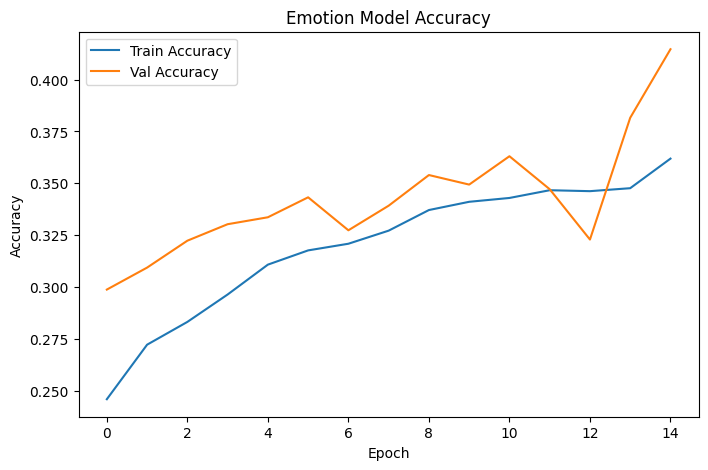

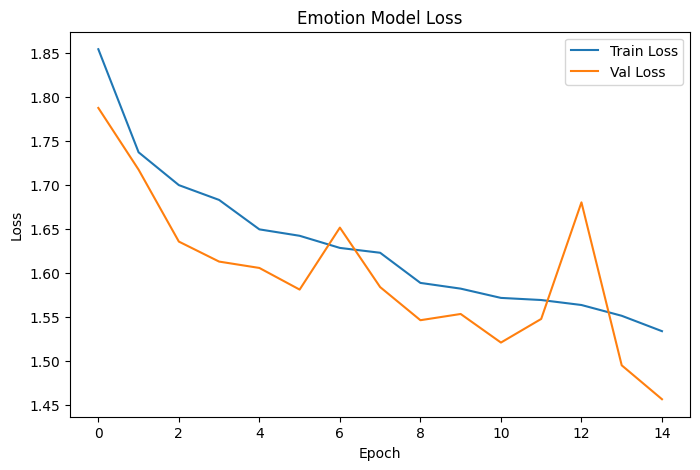

In [ ]:
# ============================================================
# EMOTION DETECTION MODEL (FER-2013)
# GOOGLE COLAB READY - FIXED VERSION
# ============================================================

import os
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# -------------------------------
# CONFIG
# -------------------------------
IMG_SIZE = 48
BATCH_SIZE = 32
EPOCHS = 15

MODEL_DIR = "/content/model"
os.makedirs(MODEL_DIR, exist_ok=True)

# -------------------------------
# DATASET PATHS
# -------------------------------
TRAIN_PATH = "/content/dataset/train"
TEST_PATH  = "/content/dataset/test"

print("Checking dataset paths...")
print("Train exists:", os.path.exists(TRAIN_PATH))
print("Test exists :", os.path.exists(TEST_PATH))

if not os.path.exists(TRAIN_PATH) or not os.path.exists(TEST_PATH):
    raise FileNotFoundError("FER dataset folders not found. Please check dataset extraction path.")

# -------------------------------
# DATA GENERATORS
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Class labels:", train_gen.class_indices)

# -------------------------------
# MODEL
# -------------------------------
model = Sequential([
    Input(shape=(48,48,1)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])

# -------------------------------
# COMPILE
# -------------------------------
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Summary:")
model.summary()

# -------------------------------
# CALLBACKS
# -------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    os.path.join(MODEL_DIR, "emotion_model.keras"),
    save_best_only=True,
    monitor='val_accuracy',
    verbose=1
)

# -------------------------------
# TRAIN
# -------------------------------
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# -------------------------------
# SAVE LABELS
# -------------------------------
with open(os.path.join(MODEL_DIR, "emotion_labels.txt"), "w") as f:
    for label in train_gen.class_indices.keys():
        f.write(label + "\n")

print("\nEmotion model saved successfully!")

# -------------------------------
# PLOT RESULTS
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Emotion Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Emotion Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
import os

os.makedirs("templates", exist_ok=True)
os.makedirs("static", exist_ok=True)

# Write index.html
with open("templates/index.html", "w") as f:
    f.write('''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Sign Language + Emotion Detection</title>
    <link rel="stylesheet" href="/static/style.css">
</head>
<body>
    <div class="container">
        <h1>🤟 Sign Language Interpreter + Emotion Detection</h1>
        <div class="video-box">
            <img src="{{ url_for(\'video_feed\') }}" width="800">
        </div>
        <div class="output-box">
            <h2>Predicted Sign: <span id="sign">None</span></h2>
            <h2>Detected Emotion: <span id="emotion">None</span></h2>
            <h2>Sentence: <span id="sentence">None</span></h2>
            <div class="buttons">
                <button onclick="speakText()">🔊 Speak Output</button>
                <button onclick="clearSentence()">🗑 Clear Sentence</button>
            </div>
        </div>
    </div>
    <script src="/static/script.js"></script>
</body>
</html>''')

# Write style.css
with open("static/style.css", "w") as f:
    f.write('''body {
    font-family: Arial, sans-serif;
    background: #111827;
    color: white;
    text-align: center;
    margin: 0; padding: 0;
}
.container { padding: 20px; }
h1 { margin-bottom: 20px; color: #00d9ff; }
.video-box img {
    border: 4px solid #00d9ff;
    border-radius: 15px;
    box-shadow: 0 0 20px rgba(0,217,255,0.4);
}
.output-box {
    margin-top: 20px;
    background: #1f2937;
    display: inline-block;
    padding: 25px;
    border-radius: 15px;
    box-shadow: 0 0 15px rgba(255,255,255,0.1);
    min-width: 400px;
}
.buttons { margin-top: 20px; }
button {
    margin: 10px; padding: 12px 20px;
    border: none; border-radius: 10px;
    background: #00d9ff; color: black;
    font-size: 16px; cursor: pointer; font-weight: bold;
}
button:hover { opacity: 0.9; }''')

# Write script.js
with open("static/script.js", "w") as f:
    f.write('''function updatePrediction() {
    fetch('/prediction')
        .then(response => response.json())
        .then(data => {
            document.getElementById("sign").innerText = data.sign;
            document.getElementById("emotion").innerText = data.emotion;
            document.getElementById("sentence").innerText = data.sentence || "None";
        });
}
setInterval(updatePrediction, 1000);

function speakText() {
    const sentence = document.getElementById("sentence").innerText;
    const sign = document.getElementById("sign").innerText;
    const emotion = document.getElementById("emotion").innerText;
    let text = sentence && sentence !== "None"
        ? "Detected sentence is " + sentence + " and emotion is " + emotion
        : "Detected sign is " + sign + " and emotion is " + emotion;
    const speech = new SpeechSynthesisUtterance(text);
    speech.lang = "en-US";
    window.speechSynthesis.speak(speech);
}

function clearSentence() {
    fetch("/clear_sentence")
        .then(response => response.json())
        .then(() => {
            document.getElementById("sentence").innerText = "None";
        });
}''')

print("✅ All files created successfully!")

✅ All files created successfully!


In [ ]:
!pip install flask flask-ngrok pyngrok -q

In [ ]:
!npm install -g localtunnel
!pip install flask -q

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 22 packages in 7s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦npm notice
npm notice New major version of npm available! 10.8.2 -> 11.12.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.12.1
npm notice To update run: npm install -g npm@11.12.1
npm notice
⠦

In [ ]:
import os

os.makedirs("/content/project/templates", exist_ok=True)
os.makedirs("/content/project/static", exist_ok=True)
os.makedirs("/content/project/uploads", exist_ok=True)
os.makedirs("/content/project/model", exist_ok=True)

print("Folders created!")

Folders created!


In [ ]:
import shutil

shutil.copy("/content/model/sign_lstm_model.keras", "/content/project/model/sign_lstm_model.keras")
shutil.copy("/content/model/sign_labels.txt", "/content/project/model/sign_labels.txt")
shutil.copy("/content/model/emotion_model.keras", "/content/project/model/emotion_model.keras")
shutil.copy("/content/model/emotion_labels.txt", "/content/project/model/emotion_labels.txt")

print("Models copied!")

Models copied!


In [ ]:
!pip install mediapipe opencv-python tensorflow -q

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import mediapipe as mp
import base64
import json
from IPython.display import display, Javascript, HTML
from google.colab import output

# -----------------------------
# LOAD YOUR MODELS
# -----------------------------
emotion_model = tf.keras.models.load_model('/content/model/emotion_model.keras')
sign_model = tf.keras.models.load_model('/content/model/sign_lstm_model.keras')

print("✅ Models loaded successfully!")

✅ Models loaded successfully!


In [ ]:
# -----------------------------
# EMOTION LABELS
# -----------------------------
emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# -----------------------------
# SIGN LABELS
# Put your actual 9 WLASL labels here
# Example based on your earlier dataset
# -----------------------------
sign_labels = [
    'book',
    'drink',
    'family',
    'father',
    'hello',
    'mother',
    'school',
    'thank_you',
    'water'
]

print("Emotion labels:", emotion_labels)
print("Sign labels:", sign_labels)

Emotion labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Sign labels: ['book', 'drink', 'family', 'father', 'hello', 'mother', 'school', 'thank_you', 'water']


In [ ]:
# Remove broken versions
!pip uninstall -y mediapipe opencv-python opencv-contrib-python protobuf

# Install compatible versions
!pip install mediapipe==0.10.14 opencv-python==4.10.0.84 protobuf==4.25.3

Found existing installation: mediapipe 0.10.33
Uninstalling mediapipe-0.10.33:
  Successfully uninstalled mediapipe-0.10.33
Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
Found existing installation: protobuf 5.29.6
Uninstalling protobuf-5.29.6:
  Successfully uninstalled protobuf-5.29.6
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 MB 9.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sourc

In [ ]:
import mediapipe as mp
print("MediaPipe version:", mp.__version__)

mp_hands = mp.solutions.hands
mp_face = mp.solutions.face_detection

print("MediaPipe loaded successfully ✅")

MediaPipe version: 0.10.14
MediaPipe loaded successfully ✅
